In [2]:
import pandas as pd
import os
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.SeqIO import write
from Bio.Seq import Seq
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, f1_score
import seaborn as sns
import sys
sys.path.append("/Users/manchuta/Documents/GitHub/vectorized_cls_metrics")
from vectorized_metrics import bvaluation


CAID3 github https://github.com/BioComputingUP/CAID/tree/main/caid

In [3]:
## mapping file for ColabFold predictions
df_mapping = pd.read_csv('mapping.txt',sep=' ', header=None, names=['name', 'id'])

#### Read CAID file with 01 labels below the sequence binding.fasta and binding_idr.fasta

In [46]:
records = []
with open('binding.fasta', 'r') as f:
    lines = f.read().splitlines()

i = 0
while i < len(lines):
    if lines[i].startswith('>'):
        name = lines[i][1:]
        seq = lines[i+1]
        label = lines[i+2] if (i+2) < len(lines) else None
        records.append({'name': name, 'sequence': seq, 'label': label})
        i += 3
    else:
        i += 1

df_caid = pd.DataFrame(records)
df_caid.head()

,name,sequence,label
0,DP03818,FVQWFSKFLGRIL,1111111111111
1,DP03914,MQARREELLAKKARLAEIKRQRELRAQQAAGRSITPSELVSPTPSR...,0000000000000000000000000000000000000000000000...
2,DP03927,MNYPDTLKSFALSEAQSSRWFQYQINPAQRGQNNSAFCARVKGLTA...,0000000000000000000000000000000000000000000000...
3,DP03930,MQGGGPRGAPIHSPSHGADSGHGLPPAVAPQRRRLTRRPGYMRSTA...,0000000000000000000000000000000000000000000000...
4,DP03984,MKNIVLASLLGFGLISSAWATETVNIHERVNNAQAPAHQMQSAAAP...,0000000000000000000000000000000000000000000000...


### binding_idr

In [26]:
### this file takes into account the disorder 
records = []
with open('binding_idr.fasta', 'r') as f:
    lines = f.read().splitlines()

i = 0
while i < len(lines):
    if lines[i].startswith('>'):
        name = lines[i][1:]
        seq = lines[i+1]
        label = lines[i+2] if (i+2) < len(lines) else None
        records.append({'name': name, 'sequence': seq, 'label': label})
        i += 3
    else:
        i += 1

df_caid_idr = pd.DataFrame(records)

### create fasta files to run the predictions

In [151]:
## to create fasta files with sequences only, without labels, for ColabFold and ProteoCast predictions
## done with the version before 15/07 CAID3
seq_records = [
    SeqRecord(Seq(row['sequence']), id=row['name'], description="")
    for _, row in df_caid.iterrows()
]

with open('CAID3_binding_sequences_only.fasta', 'w') as output_handle:
    write(seq_records, output_handle, 'fasta')

## additional/new sequences
seq_records = [
    SeqRecord(Seq(row['sequence']), id=row['name'], description="")
    for _, row in df_caid_idr.iterrows() if row['name'] not in df_mapping['name'].values
]

with open('CAID3_binding_sequences_onlyV1507.fasta', 'w') as output_handle:
    write(seq_records, output_handle, 'fasta')

In [ ]:
## quick check of the mapping and the sequences
from Bio import SeqIO

for index, row in df_caid.iterrows():
    name  = row['name'];seq = row['sequence']
    id = df_mapping.loc[df_mapping['name'] == name, 'id'].values[0]
    # Read the first sequence from a fasta file (e.g., 'example.fasta')
    record = next(SeqIO.parse(f'final/{str(id)}/1.101.fasta', 'fasta'))
    seqF = str(record.seq)
    print(seq ==seqF)

#### create segements from the binary sequence

In [47]:
def get_active_segments(sequence, binary_string):
    segments = []
    segments_index = []
    start = None

    for i, bit in enumerate(binary_string):
        if bit == '1' and start is None:
            start = i
        elif bit == '0' and start is not None:
            segments.append(sequence[start:i])
            segments_index.append((start+1, i))
            start = None

    # If the last segment goes until the end
    if start is not None:
        segments.append(sequence[start:])
        segments_index.append((start+1, len(binary_string)))

    return segments, segments_index


In [48]:
def get_state_for_position(df, position, metric='state', type='GEMME'):
    row = df[(df['start'] <= position) & (df['end'] >= position)&(df['type']==type)]
    if not row.empty:
        return round(row.iloc[0][metric], 3)
    return None

## without IDR

In [49]:
CAID_segments = []

for index, row in df_caid.iterrows():
    sequence = row['sequence']; name = row['name']
    id_prot = df_mapping[df_mapping['name'] == name]['id'].values[0]
    try:
        df_plddt = pd.read_csv(f'final/{str(id_prot)}/14.101_GEMME_pLDDT.csv', sep=',')
        df_segments = pd.read_csv(f'final/{str(id_prot)}/8.101_Segmentation.csv', sep=',')
    except:
        print(f'No prediction for {id_prot}')
        continue

    #for index_seg, row_seg in df_segments.loc[(df_segments['type'] == 'GEMME')].iterrows():
    #    start = int(row_seg['start']); stop = int(row_seg['end'])
    #    df_segments.loc[index_seg, 'pLDDT_mean'] = df_plddt.loc[start:stop, 'pLDDT'].mean()

    #print(df_segments.loc[(df_segments['type'] == 'GEMME') & (df_segments['state']!=0)])
    binary_string = row['label'].replace(' ', '')  # Remove spaces if any
    segments, segments_index = get_active_segments(sequence, binary_string)
    for start, stop in segments_index:
        positions = list(np.arange(start, stop+1))
        mean_plddt = df_plddt.loc[start:stop, 'pLDDT'].mean()
        l_localSens = [get_state_for_position(df_segments, pos) for pos in positions]
        local_sens_ratio = round(np.sum(np.isin(l_localSens, [1, 2])) / len(l_localSens), 2)
        CAID_segments.append({
            'name': name,
            'start': start,
            'stop': stop,
            'ProteoCast_LocalSens': local_sens_ratio, 
            'pLDDT': mean_plddt,
        })
df_CAID_segments = pd.DataFrame(CAID_segments)


No prediction for 0
No prediction for 23


In [50]:
df_CAID_segments['Length'] = df_CAID_segments['stop'] - df_CAID_segments['start'] + 1

In [51]:
cpt = 0
for index, row in df_caid.iterrows():
    sequence = row['sequence']; name = row['name']

    binary_string = row['label'].replace(' ', '')  # Remove spaces if any
    segments, segments_index = get_active_segments(sequence, binary_string)
    cpt+=len(segments)
print("in total there are", cpt, "segments in CAID3")

in total there are 64 segments in CAID3


In [55]:
print("#sequence CAID3", df_caid['name'].nunique(),"with ProteoCast pred", df_CAID_segments['name'].nunique())
print(f'# Segments: {df_CAID_segments.shape[0]}')
print(f' Local Sensitivity (at least 1 residue): {df_CAID_segments.loc[df_CAID_segments["ProteoCast_LocalSens"] != 0.0].shape[0]}', round(df_CAID_segments.loc[df_CAID_segments["ProteoCast_LocalSens"] != 0.0].shape[0]/df_CAID_segments.shape[0], 2))
print(f'Local Sensitivity Segments full: {df_CAID_segments.loc[df_CAID_segments["ProteoCast_LocalSens"] == 1.0].shape[0]} ({round(df_CAID_segments.loc[df_CAID_segments["ProteoCast_LocalSens"] == 1.0].shape[0] / df_CAID_segments.shape[0] * 100, 2)}%)')
print(f'Local Sensitivity Segments 50%: {df_CAID_segments.loc[df_CAID_segments["ProteoCast_LocalSens"] >= 0.5].shape[0]} ({round(df_CAID_segments.loc[df_CAID_segments["ProteoCast_LocalSens"] >= 0.5].shape[0] / df_CAID_segments.shape[0] * 100, 2)}%)')
print()
print("If we filter pLDDT<0.7")
df_CAID_segments_unstruct = df_CAID_segments.loc[df_CAID_segments["pLDDT"] < 0.7]
print(f'# Unstructured segments: {df_CAID_segments_unstruct.shape[0]}', round(df_CAID_segments_unstruct.shape[0]/df_CAID_segments.shape[0], 2))
print(f' Local Sensitivity (at least 1 residue): {df_CAID_segments_unstruct.loc[df_CAID_segments_unstruct["ProteoCast_LocalSens"] != 0.0].shape[0]}', round(df_CAID_segments_unstruct.loc[df_CAID_segments_unstruct["ProteoCast_LocalSens"] != 0.0].shape[0]/df_CAID_segments_unstruct.shape[0], 2))
print(f'Local Sensitivity Segments full: {df_CAID_segments_unstruct.loc[df_CAID_segments_unstruct["ProteoCast_LocalSens"] == 1.0].shape[0]} ({round(df_CAID_segments_unstruct.loc[df_CAID_segments_unstruct["ProteoCast_LocalSens"] == 1.0].shape[0] / df_CAID_segments_unstruct.shape[0] * 100, 2)}%)')
print(f'Local Sensitivity Segments 50%: {df_CAID_segments_unstruct.loc[df_CAID_segments_unstruct["ProteoCast_LocalSens"] >= 0.5].shape[0]} ({round(df_CAID_segments_unstruct.loc[df_CAID_segments_unstruct["ProteoCast_LocalSens"] >= 0.5].shape[0] / df_CAID_segments_unstruct.shape[0] * 100, 2)}%)')


#sequence CAID3 52 with ProteoCast pred 50
# Segments: 62
 Local Sensitivity (at least 1 residue): 53 0.85
Local Sensitivity Segments full: 25 (40.32%)
Local Sensitivity Segments 50%: 40 (64.52%)

If we filter pLDDT<0.7
# Unstructured segments: 44 0.71
 Local Sensitivity (at least 1 residue): 36 0.82
Local Sensitivity Segments full: 15 (34.09%)
Local Sensitivity Segments 50%: 27 (61.36%)


In [116]:
df_CAID_segments['Length'].describe()

count     62.000000
mean      47.500000
std      130.736219
min        5.000000
25%       13.000000
50%       18.500000
75%       35.250000
max      989.000000
Name: Length, dtype: float64

In [117]:
df_CAID_segments_unstruct.loc[df_CAID_segments_unstruct['Length']>900]

,name,start,stop,ProteoCast_LocalSens,pLDDT,Length
52,DP04280,1,989,0.42,0.492577,989


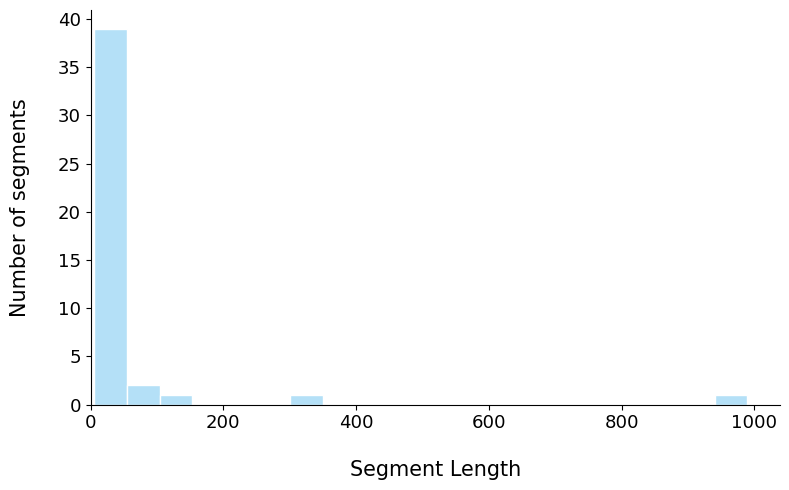

In [119]:
plt.figure(figsize=(8, 5))
plt.hist(df_CAID_segments_unstruct['Length'], bins=20, edgecolor='white', color='#B4E0F7')
#plt.hist(df_CAID_segments['Length'], bins=20, edgecolor='black', alpha=0.5)
plt.xlabel('Segment Length', fontsize=15, labelpad=20)
plt.ylabel('Number of segments', fontsize=15, labelpad=20)
plt.grid(False)
plt.xlim(0)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig('CAID3_segmentUnstruct_length_distribution.jpg', dpi=700)
plt.show()


(62,)


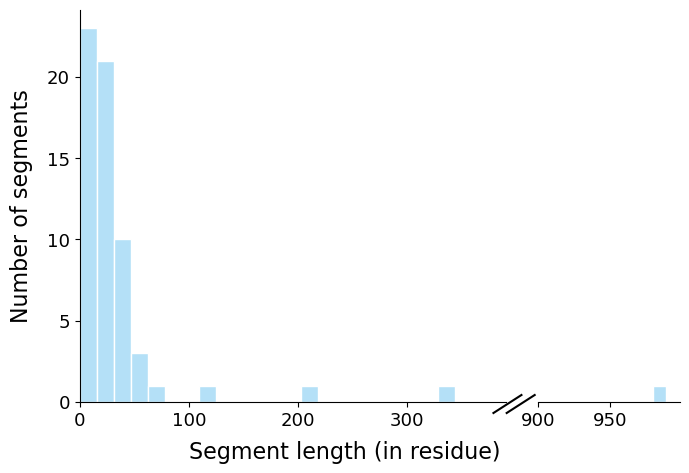

In [169]:
# Data
data = df_CAID_segments['Length']#df_CAID_segments_unstruct['Length']
print(data.shape)
# Create subplots with shared y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(7, 4.5), gridspec_kw={'width_ratios': [3, 1]})

# Plot histograms in two parts
ax1.hist(data, bins=25, edgecolor='white', color='#B4E0F7', range=(0, 390))
ax2.hist(data, bins=10, edgecolor='white', color='#B4E0F7', range=(900, data.max()))

# Set axis limits
ax1.set_xlim(0, 390)
ax2.set_xlim(900, data.max()+10)

# Remove spines between axes
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

ax1.tick_params(labelright=False)


# Diagonal size
d = 0.02

# Get figure coordinates for ax1 and ax2 edges
fig.subplots_adjust(wspace=0.05) # small space between plots
x1 = ax1.get_position().x1 +0.04 # right edge of ax1
x2 = ax2.get_position().x0 + 0.04 # left edge of ax2
y0 = ax1.get_position().y0-0.02 # bottom
y1 = ax1.get_position().y1-0.02 # top

# Draw diagonals in figure coordinates
kwargs = dict(transform=fig.transFigure, color='k', clip_on=False)

# Bottom diagonals
fig.lines.append(plt.Line2D((x1 - d, x1 + d), (y0 - d, y0 + d), **kwargs))
fig.lines.append(plt.Line2D((x2 - d, x2 + d), (y0 - d, y0 + d), **kwargs))


# Labels and style
fig.text(0.5, -0.03, 'Segment length (in residue)', ha='center', fontsize=16)
# after creating subplots
#fig.supxlabel('Segment length (residues)', fontsize=16)

ax1.set_ylabel('Number of segments', fontsize=16, labelpad=10)
ax1.tick_params(axis='both', labelsize=13)
ax2.tick_params(axis='both', labelsize=13)
# Remove y-axis ticks and labels on right subplot
ax2.tick_params(labelleft=False, left=False)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
#plt.tight_layout()
fig.tight_layout(rect=[0, 0, 1, 1])  # leave a bit of bottom room
plt.savefig('CAID3_segmentUnstruct_length_distribution_broken_axis.jpg', dpi=700, bbox_inches='tight', pad_inches=0.05)
plt.show()

In [ ]:
df_CAID_segments

,name,start,stop,ProteoCast_LocalSens,pLDDT,Length
0,DP03914,50,64,1.00,0.640333,15
1,DP03927,1073,1082,0.00,0.609300,10
2,DP03930,774,829,1.00,0.845982,56
3,DP03984,59,72,1.00,0.794500,14
4,DP03984,80,90,1.00,0.800909,11
...,...,...,...,...,...,...
57,DP04337,372,377,1.00,0.379667,6
58,DP04341,399,439,0.07,0.352220,41
59,DP04379,1,110,0.72,0.597918,110
60,DP04388,65,97,0.76,0.294788,33


[  0.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.
  70.  75.  80.  85.  90.  95. 100.]
[ 2.5  7.5 12.5 17.5 22.5 27.5 32.5 37.5 42.5 47.5 52.5 57.5 62.5 67.5
 72.5 77.5 82.5 87.5 92.5 97.5]


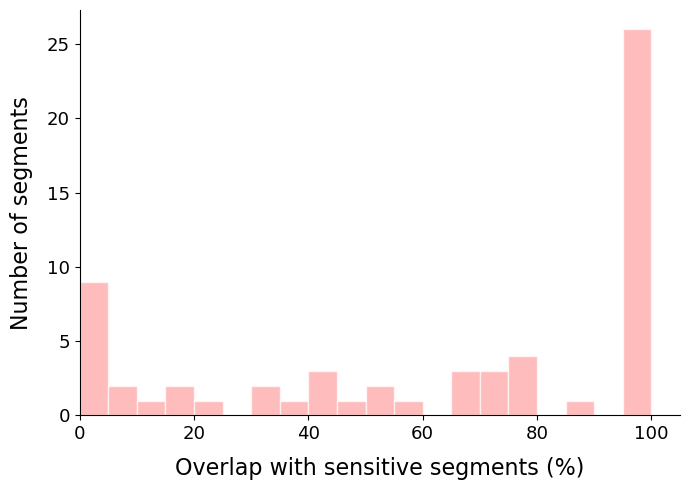

In [132]:
plt.figure(figsize=(7,5))
# Compute bin centers
bins = np.linspace(0, 100.0, 21)
counts, bins, _ = plt.hist(df_CAID_segments['ProteoCast_LocalSens']*100, bins=bins, edgecolor='white', color='#FF9999', alpha=0.65)
print(bins)
#plt.hist(df_CAID_segments['Length'], bins=20, edgecolor='black', alpha=0.5)
plt.xlabel('Overlap with sensitive segments (%)', fontsize=16, labelpad=10)
plt.ylabel('Number of segments', fontsize=16, labelpad=10)
plt.grid(False)
plt.xlim(0)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
print(bin_centers)
tick_positions = list(bin_centers[::4])
tick_labels = [f"{x:.1f}" for x in tick_positions]

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig('CAID3_segmentUnstruct_localSensitivity.jpg', dpi=700)
plt.show()


#### check our definition of disorder and the one given by CAID3

## With IDR

In [60]:
def get_disorder_segments(sequence, binary_string):
    segments = []
    segments_index = []
    start = None

    for i, bit in enumerate(binary_string):
        if (bit == '1' or bit == '0') and start is None:
            start = i
        elif bit == '-' and start is not None:
            segments.append(sequence[start:i])
            segments_index.append((start+1, i))
            start = None

    # If the last segment goes until the end
    if start is not None:
        segments.append(sequence[start:])
        segments_index.append((start+1, len(binary_string)))

    return segments, segments_index


In [61]:
CAID_IDR_segments = []

for index, row in df_caid_idr.iterrows():
    sequence = row['sequence']; name = row['name']
    
    try:
        id_prot = df_mapping[df_mapping['name'] == name]['id'].values[0]
    except:
        print(f'No mapping found for {name}')
        print(sequence)
        continue
    try:
        df_plddt = pd.read_csv(f'final/{str(id_prot)}/14.101_GEMME_pLDDT.csv', sep=',')
        df_segments = pd.read_csv(f'final/{str(id_prot)}/8.101_Segmentation.csv', sep=',')
    except:
        print(f'No prediction for {id_prot}')
        continue

    binary_string = row['label'].replace(' ', '')  # Remove spaces if any
    segments, segments_index = get_disorder_segments(sequence, binary_string)
   
    for start, stop in segments_index:
        positions = list(np.arange(start, stop+1))
        mean_plddt = df_plddt.loc[start:stop, 'pLDDT'].mean()
        l_localSens = [get_state_for_position(df_segments, pos) for pos in positions]
        local_sens_ratio = round(np.sum(np.isin(l_localSens, [1, 2])) / len(l_localSens), 2)
        CAID_IDR_segments.append({
            'name': name,
            'start': start,
            'stop': stop,
            'ProteoCast_LocalSens': local_sens_ratio, 
            'pLDDT': mean_plddt,
        })
df_CAID_IDR_segments = pd.DataFrame(CAID_IDR_segments)


No prediction for 0
No prediction for 23


#### calculate the coverage of Proteocast #aa_ProteoCast/ #aa_all

##### Length of all sequences

In [41]:
df_caid['Length'] = df_caid['sequence'].apply(len)
df_caid['Length'].sum(), df_caid['name'].nunique()
print(df_caid['name'].nunique())
print('28263 total number of aa in binding sequences')

52
28263 total number of aa in binding sequences


In [42]:
df_caid.loc[~df_caid.index.isin([0, 23]), 'Length'].sum()/df_caid['Length'].sum()

0.9964264232388635

#### comparison with other tools submitted to CAID3


In [131]:
def get_bindingdisorder_segments(sequence, binary_string):
    segments = []
    segments_index = []
    start = None

    for i, bit in enumerate(binary_string):
        if bit == '1'  and start is None:
            start = i
        elif (bit == '-' or bit == '0') and start is not None:
            segments.append(sequence[start:i])
            segments_index.append((start+1, i))
            start = None

    # If the last segment goes until the end
    if start is not None:
        segments.append(sequence[start:])
        segments_index.append((start+1, len(binary_string)))

    return segments, segments_index

In [141]:
CAID_segments_all = []

for index, row in df_caid.iterrows():
    sequence = row['sequence']; name = row['name']
    binary_string = row['label'].replace(' ', '')  # Remove spaces if any
    segments, segments_index = get_bindingdisorder_segments(sequence, binary_string)

    try:
        id_prot = df_mapping[df_mapping['name'] == name]['id'].values[0]
    except:
        print(f'No mapping found for {name}')
        print(sequence)
        continue

    try:
        df_plddt = pd.read_csv(f'final/{str(id_prot)}/14.101_GEMME_pLDDT.csv', sep=',')
        df_segments = pd.read_csv(f'final/{str(id_prot)}/8.101_Segmentation.csv', sep=',')
    except:
        print(f'No prediction for {id_prot}')
        continue


    for start, stop in segments_index:
        positions = list(np.arange(start, stop+1))
        mean_plddt = df_plddt.loc[start:stop, 'pLDDT'].mean()
        l_localSens = [get_state_for_position(df_segments, pos) for pos in positions]
        local_sens_ratio = round(np.sum(np.isin(l_localSens, [1, 2])) / len(l_localSens), 2)
        CAID_segments_all.append({
            'name': name,
            'start': start,
            'stop': stop,
            'ProteoCast_LocalSens': local_sens_ratio,
            'pLDDT': mean_plddt
        })

df_CAID_segments_all = pd.DataFrame(CAID_segments_all)


No prediction for 0
No prediction for 23


In [145]:
print('segment full', df_CAID_segments_all.loc[df_CAID_segments_all['ProteoCast_LocalSens'] == 1.0].shape[0], df_CAID_segments_all.loc[df_CAID_segments_all['ProteoCast_LocalSens'] == 1.0].shape[0] / df_CAID_segments_all.shape[0] * 100)
print('segment at least 1 residue', df_CAID_segments_all.loc[df_CAID_segments_all['ProteoCast_LocalSens'] != 0.0].shape[0], df_CAID_segments_all.loc[df_CAID_segments_all['ProteoCast_LocalSens'] != 0.0].shape[0] / df_CAID_segments_all.shape[0] * 100)


segment full 25 40.32258064516129
segment at least 1 residue 53 85.48387096774194


In [146]:
df_CAID_segments_all.shape[0]

62

In [135]:
df_CAID_segments_all['Length'] = df_CAID_segments_all['stop'] - df_CAID_segments_all['start'] + 1
df_CAID_segments_all['Length'].sum(), df_CAID_segments_all['name'].nunique()

(2991, 52)

#### protein to exclude to compare on the same basis

In [137]:
p_toExclude = ['DP03818', 'DP04190']

In [138]:
##list of the 10 top performaing tools
l_top10CAID3_binding = ['DisoFLAG-LB', 'IPA-AF2-Protein-bind', 'IPA-All-bind', 'AlphaFold-binding', 'AlphaFold3-binding', 'AIUPred-2-binding', 'IPA-Protein-bind', 'DeepDISObind-nucleic', 'DeepDISObind-all', 'DeepDISObind-protein']
l_top10CAID3_binding_IDR = ['bindEmbed21IDR-rawGeneral', 'bindEmbed21IDR-idrGeneral', 'LIPNet', 'ProBiPred-protein', 'AIUPred-2-binding', 'bindEmbed21IDR-rawNuc', 'bindEmbed21IDR-idrNuc', 'DisoRDPbind-rna', 'MoRFchibi-light', 'MoRFchibi-web' ]
dir_results_CAID3 = '/Users/manchuta/Desktop/CAID3/predictions/'

def read_caid3_prediction(tool):
    results = []
    with open(os.path.join(dir_results_CAID3, f'{tool}.caid'), 'r') as f:
        current_id = None
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                current_id = line[1:]
            elif line:
                parts = line.split()
                if len(parts) == 3:
                    pos, aa, score = parts
                    results.append({'id': current_id, 'pos': int(pos), 'aa': aa, 'score': float(score)})
                if len(parts) == 4:
                    pos, aa, score, _ = parts
                    results.append({'id': current_id, 'pos': int(pos), 'aa': aa, 'score': float(score)})
    return pd.DataFrame(results)



In [139]:
df = read_caid3_prediction('IPA-All-bind')
df = df.loc[df['id'].isin(df_CAID_segments_all['name'].tolist())].copy()
print(df.shape)
df['binding'] = 0
for index, row in df_CAID_segments_all.iterrows():
    df.loc[(df['id'] == row['name']) & (df['pos'] >= row['start']) & (df['pos'] <= row['stop']), 'binding'] = 1
print(df.loc[df['binding'] == 1].shape)
df_CAIDall = df.loc[~df['id'].isin(p_toExclude)].copy()

(28263, 4)
(2991, 5)


##### add idr values of CAID3

In [62]:
for protein in df_CAIDall['id'].unique():
    idr_vector = list(df_caid_idr.loc[df_caid_idr['name'] == protein, 'label'].values[0])
    #print(idr_vector)
    df_CAIDall.loc[df_CAIDall['id']==protein, 'idr_caid'] = idr_vector

In [63]:
print(f"Dataset considering only disordered regions include {df_CAIDall.loc[df_CAIDall['idr_caid']!='-'].shape[0]} residues")

Dataset considering only disordered regions include 7640 residues


#### create the same type of dataframe as for other caid tools, all the proteins together with 0 or 1 for each residue

In [64]:
for name in df_CAIDall['id'].unique():

    id_prot = df_mapping[df_mapping['name'] == name]['id'].values[0]

    try:
        df_segments = pd.read_csv(f'final/{str(id_prot)}/8.101_Segmentation.csv', sep=',')        
        df_segments = df_segments.loc[df_segments['type'] == 'GEMME'].copy()

        ## uninformed segmentation (without pLDDT)
        df_segments_uninformed = pd.read_csv(f'final/{str(id_prot)}/101_UninformedSegmentation.csv', sep=',')
        df_plddt = pd.read_csv(f'final/{str(id_prot)}/14.101_GEMME_pLDDT.csv', sep=',')
    except:
        continue

    # Get the length of the full sequence (from the last end)
    sequence_length = df_segments['end'].max()

    # Initialize vector of zeros
    binary_vector = np.zeros(sequence_length, dtype=int)
    binary_vector_uninformed = np.zeros(sequence_length, dtype=int)
    # Initialize mean sensitivity vector
    mean_sensitivity_vector = np.zeros(sequence_length, dtype=float)
    mean_sensitivity_vector_uninformed = np.zeros(sequence_length, dtype=float)
    
    # Fill with 1 where state != 0
    for _, row in df_segments.iterrows():
        if row['state'] != 0:
            binary_vector[row['start'] - 1 : row['end']] = row['state']  # -1 because indexing starts at 0
        ##mean sensitivity
        mean_sensitivity_vector[row['start'] - 1 : row['end']] = row['mean']

    # Fill with 1 where state != 0
    for _, row in df_segments_uninformed.iterrows():
        if row['state'] != 0:
            binary_vector_uninformed[row['start'] - 1 : row['end']] = row['state']  # -1 because indexing starts at 0
        ##mean sensitivity
        mean_sensitivity_vector_uninformed[row['start'] - 1 : row['end']] = row['mean']

    #print(df_CAIDall.loc[df_CAIDall['id']==name].shape[0], len(binary_vector))
    df_CAIDall.loc[df_CAIDall['id']==name, 'ProteoCast'] = binary_vector.tolist()
    df_CAIDall.loc[df_CAIDall['id']==name, 'ProteoCast_binary'] = df_CAIDall.loc[df_CAIDall['id']==name, 'ProteoCast'].apply(lambda x: 1 if x in [1.0, 2.0] else 0.0) 
    df_CAIDall.loc[df_CAIDall['id']==name, 'ProteoCast_uninformed'] = binary_vector_uninformed.tolist()
    df_CAIDall.loc[df_CAIDall['id']==name, 'pLDDT'] = df_plddt['pLDDT'].tolist()
    df_CAIDall.loc[df_CAIDall['id']==name, 'GEMME_mu'] = df_plddt['GEMME_mean'].tolist()
    df_CAIDall.loc[df_CAIDall['id']==name, 'mean_sensitivity'] = mean_sensitivity_vector.tolist()
    df_CAIDall.loc[df_CAIDall['id']==name, 'mean_sensitivity_uninformed'] = mean_sensitivity_vector_uninformed.tolist()


## add all other models

In [65]:
for model in  list(set(l_top10CAID3_binding) | set(l_top10CAID3_binding_IDR)) :
    df_model = read_caid3_prediction(model)
    df_model = df_model.loc[df_model['id'].isin(df_CAID_segments_all['name'].tolist())].copy()
    df_model = df_model.loc[~df_model['id'].isin(p_toExclude)].copy()
    if df_model.shape[0]==df_CAIDall.shape[0]:
        print(f"Adding model {model} to df_CAIDall")
        df_model.rename(columns={'score': model}, inplace=True)
        df_CAIDall = df_CAIDall.merge(df_model[['id', 'pos', 'aa', model]], on=['id', 'pos', 'aa'], how='left')
    

Adding model IPA-Protein-bind to df_CAIDall
Adding model AlphaFold-binding to df_CAIDall
Adding model MoRFchibi-light to df_CAIDall
Adding model AIUPred-2-binding to df_CAIDall
Adding model bindEmbed21IDR-rawGeneral to df_CAIDall
Adding model DisoRDPbind-rna to df_CAIDall
Adding model IPA-All-bind to df_CAIDall
Adding model DeepDISObind-all to df_CAIDall
Adding model ProBiPred-protein to df_CAIDall
Adding model DeepDISObind-protein to df_CAIDall
Adding model bindEmbed21IDR-rawNuc to df_CAIDall
Adding model MoRFchibi-web to df_CAIDall
Adding model AlphaFold3-binding to df_CAIDall
Adding model bindEmbed21IDR-idrGeneral to df_CAIDall
Adding model bindEmbed21IDR-idrNuc to df_CAIDall
Adding model LIPNet to df_CAIDall
Adding model DeepDISObind-nucleic to df_CAIDall


In [66]:
df_CAIDall_plddt = df_CAIDall.loc[(df_CAIDall['pLDDT'] < 0.7)].copy()
df_CAIDall_plddt.shape

(13706, 30)

In [44]:
df_CAIDall.columns

Index(['id', 'pos', 'aa', 'score', 'binding', 'idr_caid', 'ProteoCast',
       'ProteoCast_binary', 'ProteoCast_uninformed', 'pLDDT', 'GEMME_mu',
       'mean_sensitivity', 'mean_sensitivity_uninformed', 'IPA-Protein-bind',
       'AlphaFold-binding', 'MoRFchibi-light', 'AIUPred-2-binding',
       'bindEmbed21IDR-rawGeneral', 'DisoRDPbind-rna', 'IPA-All-bind',
       'DeepDISObind-all', 'ProBiPred-protein', 'DeepDISObind-protein',
       'bindEmbed21IDR-rawNuc', 'MoRFchibi-web', 'AlphaFold3-binding',
       'bindEmbed21IDR-idrGeneral', 'bindEmbed21IDR-idrNuc', 'LIPNet',
       'DeepDISObind-nucleic', 'delta_mu'],
      dtype='object')

In [45]:
df_CAIDall_idr = df_CAIDall.loc[df_CAIDall['idr_caid'] != '-'].copy()
print(f'binding residues {df_CAIDall_idr["binding"].values.sum()}, {df_CAIDall_idr.loc[df_CAIDall_idr["binding"] == 1, "ProteoCast_binary"].values.sum()}')
print(f'{df_CAIDall_idr.loc[(df_CAIDall_idr["binding"] == 1)&(df_CAIDall_idr["ProteoCast"] == 2)].shape[0]}')

binding residues 2945, 1563.0
1111


In [74]:
df_CAIDall.loc[df_CAIDall['binding']==1, 'binding'].sum()

2945

In [77]:
df_CAIDall_idr.loc[df_CAIDall_idr['pLDDT']<0.7]

,id,pos,aa,score,binding,idr_caid,ProteoCast,ProteoCast_binary,ProteoCast_uninformed,pLDDT,...,ProBiPred-protein,DeepDISObind-protein,bindEmbed21IDR-rawNuc,MoRFchibi-web,AlphaFold3-binding,bindEmbed21IDR-idrGeneral,bindEmbed21IDR-idrNuc,LIPNet,DeepDISObind-nucleic,delta_mu
30,DP03914,31,G,0.807,0,0,0.0,0.0,0.0,0.508,...,0.012,0.341,0.000,0.656,0.938,0.001,0.000,0.557,0.135,0.000000
31,DP03914,32,R,0.801,0,0,0.0,0.0,0.0,0.454,...,0.005,0.354,0.002,0.658,0.875,0.003,0.002,0.427,0.102,0.000000
32,DP03914,33,S,0.793,0,0,0.0,0.0,0.0,0.376,...,0.002,0.354,0.000,0.672,0.854,0.002,0.000,0.252,0.150,0.000000
33,DP03914,34,I,0.805,0,0,0.0,0.0,0.0,0.355,...,0.011,0.354,0.000,0.694,0.821,0.003,0.000,0.317,0.523,0.000000
34,DP03914,35,T,0.809,0,0,0.0,0.0,0.0,0.374,...,0.001,0.354,0.000,0.694,0.826,0.001,0.000,0.134,0.150,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27805,DP04388,200,G,0.562,0,0,1.0,1.0,0.0,0.467,...,0.041,0.269,0.000,0.401,0.834,0.009,0.000,0.938,0.091,0.130263
27806,DP04388,201,S,0.548,0,0,1.0,1.0,0.0,0.512,...,0.254,0.270,0.000,0.417,0.855,0.004,0.000,0.963,0.113,0.130263
27807,DP04388,202,M,0.548,0,0,2.0,1.0,1.0,0.526,...,0.370,0.273,0.000,0.457,0.867,0.005,0.000,0.960,0.076,0.239681
28052,DP04391,30,F,0.561,1,1,2.0,1.0,1.0,0.677,...,0.549,0.082,0.000,0.690,0.901,0.170,0.000,0.984,0.013,0.350534


Number of true binding residues: 2945 out of 7640
ProteoCast: TPR=0.531, FPR=0.415, F1=0.484
bindEmbed21IDR-rawGeneral: TPR=0.744, FPR=0.535, Threshold=0.003, F1=0.573
bindEmbed21IDR-idrGeneral: TPR=0.739, FPR=0.534, Threshold=0.003, F1=0.571
LIPNet: TPR=0.654, FPR=0.469, Threshold=0.449, F1=0.545
ProBiPred-protein: TPR=0.488, FPR=0.314, Threshold=0.021, F1=0.491
AIUPred-2-binding: TPR=0.652, FPR=0.494, Threshold=0.122, F1=0.535
bindEmbed21IDR-rawNuc: TPR=0.463, FPR=0.317, Threshold=0.001, F1=0.470
bindEmbed21IDR-idrNuc: TPR=0.458, FPR=0.316, Threshold=0.001, F1=0.467
DisoRDPbind-rna: TPR=0.295, FPR=0.184, Threshold=0.055, F1=0.371
MoRFchibi-light: TPR=0.573, FPR=0.450, Threshold=0.602, F1=0.500
MoRFchibi-web: TPR=0.841, FPR=0.759, Threshold=0.512, F1=0.551


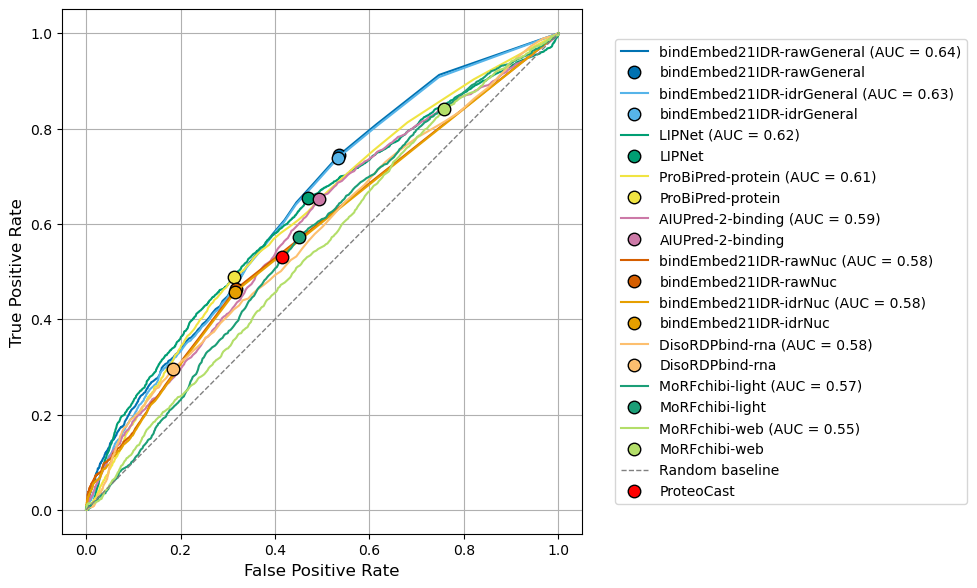

{'bindEmbed21IDR-rawGeneral': 0.5728485482605284,
 'bindEmbed21IDR-idrGeneral': 0.5706044316244919,
 'MoRFchibi-web': 0.5512634977179116,
 'LIPNet': 0.5446579988694178,
 'AIUPred-2-binding': 0.5345955728804122,
 'MoRFchibi-light': 0.5002223869532987,
 'ProBiPred-protein': 0.4908625106746371,
 'ProteoCast_binary': 0.484275755228505,
 'bindEmbed21IDR-rawNuc': 0.47032436162870944,
 'bindEmbed21IDR-idrNuc': 0.4668627790275134,
 'DisoRDPbind-rna': 0.3710987601539119}

In [71]:
d_f1score = {}
#df_tmp = df_CAIDall_plddt.copy()
#df_tmp = df_CAIDall.copy()
df_tmp = df_CAIDall.loc[df_CAIDall['idr_caid']!='-'].copy()

#df_tmp = df_CAIDall_plddt.loc[df_CAIDall_plddt['idr_caid']!='-'].copy()


##  ProteoCast point

#df_tmp['ProteoCast_binary'] = df_tmp['ProteoCast'].apply(lambda x: 1 if x == 2.0 else 0.0) ## only 2 is considered as detected
df_tmp['ProteoCast_binary'] = df_tmp['ProteoCast'].apply(lambda x: 1 if x in [1.0, 2.0] else 0.0) ## 1 and 2 are considered as detected

#df_tmp['ProteoCast_binary'] = df_tmp['ProteoCast_uninformed'].apply(lambda x: 1 if x in [1.0, 2.0] else 0.0) ## 1 and 2 are considered as detected
#df_tmp['ProteoCast_binary'] = df_tmp['ProteoCast_uninformed'].apply(lambda x: 1 if x == 2.0 else 0.0) ## only 2 is considered as detected


# Get true and predicted labels
y_true = df_tmp['binding']
print(f"Number of true binding residues: {y_true.sum()} out of {len(y_true)}")
y_pred = df_tmp['ProteoCast_binary']
# Compute confusion matrix: [[TN, FP], [FN, TP]]
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
# Compute TPR (Recall or Sensitivity) and FPR
tpr_ProteoCast = tp / (tp + fn) if (tp + fn) > 0 else 0
fpr_ProteoCast = fp / (fp + tn) if (fp + tn) > 0 else 0
f1 = f1_score(y_true, y_pred)
d_f1score['ProteoCast_binary'] = f1
print(f"ProteoCast: TPR={tpr_ProteoCast:.3f}, FPR={fpr_ProteoCast:.3f}, F1={f1:.3f}")


palette = [
    "#0072B2",  # Blue
    "#56B4E9",  # Light Blue
    "#009E73",  # Green
    "#F0E442",  # Yellow
    "#CC79A7",  # Purple
    "#D55E00",  # Orange
    "#E69F00",  # Gold
    "#FDBF6F",  # Peach
    "#1B9E77",  # Teal
    "#B3DE69",  # Light Green
]

### ROC curves for all other models

plt.figure(figsize=(10, 6))

for color, model in zip(palette, l_top10CAID3_binding_IDR):
    try:
        temp_df = df_tmp[['binding', model]].dropna()
    except:
        print(f"Model {model} not found in the DataFrame.")
        continue
    
    y_true = temp_df['binding']
    y_score = temp_df[model]
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    """if len(fpr) > 2:
        optimal_idxs = np.where(np.r_[True, np.logical_or(np.diff(fpr, 2), np.diff(tpr, 2)), True])[0]
        fpr = fpr[optimal_idxs]
        tpr = tpr[optimal_idxs]
        thresholds = thresholds[optimal_idxs]
    tpr = np.r_[0, tpr]
    fpr = np.r_[0, fpr]
    thresholds = np.r_[thresholds[0] + 1, thresholds]
    """

    roc_auc = auc(fpr, tpr)
    # Youden's J statistic
    j_scores = tpr - fpr
    best_index = j_scores.argmax()
    best_threshold = thresholds[best_index]

    # Binary predictions at best threshold
    y_pred = (y_score >= best_threshold).astype(int)
    f1 = f1_score(y_true, y_pred)
    d_f1score[model] = f1
    # Plot ROC curve and dot with same color
    curve, = plt.plot(fpr, tpr, label=f'{model} (AUC = {roc_auc:.2f})', color=color)
    plt.plot(fpr[best_index], tpr[best_index], 'o', markersize=9, label=model, color=curve.get_color(), markeredgecolor='black', markeredgewidth=1)

    print(f"{model}: TPR={tpr[best_index]:.3f}, FPR={fpr[best_index]:.3f}, Threshold={best_threshold:.3f}, F1={f1:.3f}")

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random baseline')
plt.plot(fpr_ProteoCast, tpr_ProteoCast, 'o', color='red', markersize=9, label='ProteoCast', markeredgecolor='black', markeredgewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
#plt.title('ROC Curve for Binding Prediction (pLDDT<0.7)', fontsize=14)
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()
d_f1score_sorted = dict(sorted(d_f1score.items(), key=lambda item: item[1], reverse=True))
d_f1score_sorted

##### ProteoCast ROC with sensitivity 

bindEmbed21IDR-rawGeneral: TPR=0.744, FPR=0.535, Threshold=0.003, F1=0.573
bindEmbed21IDR-idrGeneral: TPR=0.739, FPR=0.534, Threshold=0.003, F1=0.571
LIPNet: TPR=0.654, FPR=0.469, Threshold=0.449, F1=0.545
ProBiPred-protein: TPR=0.488, FPR=0.314, Threshold=0.021, F1=0.491
AIUPred-2-binding: TPR=0.652, FPR=0.494, Threshold=0.122, F1=0.535
bindEmbed21IDR-rawNuc: TPR=0.463, FPR=0.317, Threshold=0.001, F1=0.470
bindEmbed21IDR-idrNuc: TPR=0.458, FPR=0.316, Threshold=0.001, F1=0.467
DisoRDPbind-rna: TPR=0.295, FPR=0.184, Threshold=0.055, F1=0.371
MoRFchibi-light: TPR=0.573, FPR=0.450, Threshold=0.602, F1=0.500
MoRFchibi-web: TPR=0.841, FPR=0.759, Threshold=0.512, F1=0.551
mean_sensitivity: TPR=0.355, FPR=0.192, Threshold=0.466, F1=0.427


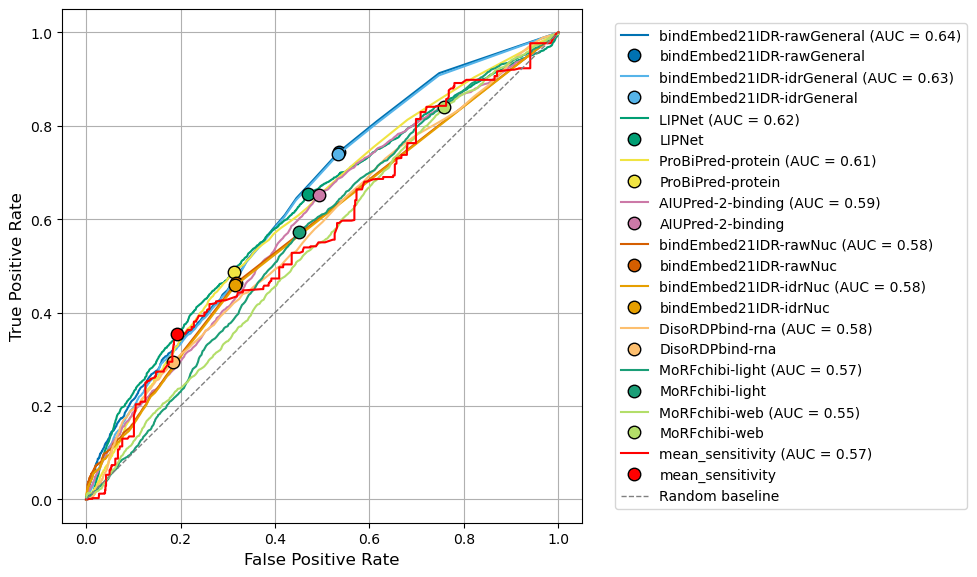

{'bindEmbed21IDR-rawGeneral': 0.5728485482605284,
 'bindEmbed21IDR-idrGeneral': 0.5706044316244919,
 'MoRFchibi-web': 0.5512634977179116,
 'LIPNet': 0.5446579988694178,
 'AIUPred-2-binding': 0.5345955728804122,
 'MoRFchibi-light': 0.5002223869532987,
 'ProBiPred-protein': 0.4908625106746371,
 'bindEmbed21IDR-rawNuc': 0.47032436162870944,
 'bindEmbed21IDR-idrNuc': 0.4668627790275134,
 'mean_sensitivity': 0.4274028629856851,
 'DisoRDPbind-rna': 0.3710987601539119}

In [72]:

#df_tmp = df_CAIDall_plddt.copy()
#df_tmp = df_CAIDall.copy()
df_tmp = df_CAIDall.loc[df_CAIDall['idr_caid']!='-'].copy()

d_f1score = {}
palette = [
    "#0072B2",  # Blue
    "#56B4E9",  # Light Blue
    "#009E73",  # Green
    "#F0E442",  # Yellow
    "#CC79A7",  # Purple
    "#D55E00",  # Orange
    "#E69F00",  # Gold
    "#FDBF6F",  # Peach
    "#1B9E77",  # Teal
    "#B3DE69",  # Light Green
    'red'
]
### ROC curves for all other models

plt.figure(figsize=(10, 6))

for color, model in zip(palette, l_top10CAID3_binding_IDR+['mean_sensitivity']): #mean_sensitivity_uninformed or GEMME_mu
    try:
        temp_df = df_tmp[['binding', model]].dropna()
    except:
        print(f"Model {model} not found in the DataFrame.")
        continue
    
    y_true = temp_df['binding']
    y_score = temp_df[model]
    fpr, tpr, thresh = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    # Youden's J statistic
    j_scores = tpr - fpr
    best_index = j_scores.argmax()
    best_threshold = thresh[best_index]

    # Binary predictions at best threshold
    y_pred = (y_score >= best_threshold).astype(int)
    f1 = f1_score(y_true, y_pred)
    d_f1score[model] = f1
    # Plot ROC curve and dot with same color
    curve, = plt.plot(fpr, tpr, label=f'{model} (AUC = {roc_auc:.2f})', color=color)
    plt.plot(fpr[best_index], tpr[best_index], 'o', markersize=9, label=model, color=curve.get_color(), markeredgecolor='black', markeredgewidth=1)

    print(f"{model}: TPR={tpr[best_index]:.3f}, FPR={fpr[best_index]:.3f}, Threshold={best_threshold:.3f}, F1={f1:.3f}")

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random baseline')
#plt.plot(fpr_ProteoCast, tpr_ProteoCast, 'o', color='red', markersize=9, label='ProteoCast (2)', markeredgecolor='black', markeredgewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
#plt.title('ROC Curve for Binding Prediction (pLDDT<0.7)', fontsize=14)
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()
d_f1score_sorted = dict(sorted(d_f1score.items(), key=lambda item: item[1], reverse=True))
d_f1score_sorted


#### ROC for delta mu 

In [11]:
for name in df_CAIDall['id'].unique():
    id_prot = df_mapping[df_mapping['name'] == name]['id'].values[0]

    try:
        df_segments = pd.read_csv(f'final/{str(id_prot)}/8.101_Segmentation.csv', sep=',')        
        df_segments = df_segments.loc[df_segments['type'] == 'GEMME'].copy()
    except:
        print(f'No prediction for {id_prot}')
        continue

    # Add columns for deltas
    df_segments['delta_prev'] = np.nan
    df_segments['delta_next'] = np.nan
    df_segments['delta_score'] = 0.0  # Score assigned to the segment
    # Get the length of the full sequence (from the last end)
    sequence_length = df_segments['end'].max()
    delta_mu = np.zeros(sequence_length, dtype=float)

    # Fill with 1 where state != 0
    for index, row in df_segments.iterrows():
        mu_i = row['mean']
        if index>0:
            mu_prev = df_segments.loc[index - 1, 'mean']
            df_segments.loc[index, 'delta_prev'] = mu_i - mu_prev
        if index < len(df_segments) - 1:
            mu_next = df_segments.loc[index + 1, 'mean']
            df_segments.loc[index, 'delta_next'] = mu_i - mu_next

        

        # Compute score depending on segment state
        state = df_segments.loc[index, 'state']
        #score = max(df_segments.loc[index, ['delta_prev', 'delta_next']].dropna())
        if state == 2:  # peak
            score = max(df_segments.loc[index, ['delta_prev', 'delta_next']].dropna())
        elif state == 1:  # valley
            score = max(df_segments.loc[index, ['delta_prev', 'delta_next']].dropna())
            #score = df_segments.loc[index, ['delta_prev', 'delta_next']].dropna().sum()#-min(df_segments.loc[index, ['delta_prev', 'delta_next']].dropna())
            #score = -min(df_segments.loc[index, ['delta_prev', 'delta_next']].dropna())
        else:
            score = 0

        delta_mu[row['start'] - 1 : row['end']] = score


    #print(df_CAIDall.loc[df_CAIDall['id']==name].shape[0], len(binary_vector))
    df_CAIDall.loc[df_CAIDall['id']==name, 'delta_mu'] = delta_mu.tolist()
    

In [7]:
df_CAIDall.rename(columns={'delta_mu': 'ProteoCast-delta-mu_segment', 'GEMME_mu': 'ProteoCast-mu_residue'}, inplace=True)

Number of true binding residues: 2945 out of 7640
ProteoCast: TPR=0.531, FPR=0.415, F1=0.484
bindEmbed21IDR-rawGeneral: TPR=0.744, FPR=0.535, Threshold=0.003, F1=0.573
Cross-entropy (log-loss): 2.6759
bindEmbed21IDR-idrGeneral: TPR=0.739, FPR=0.534, Threshold=0.003, F1=0.571
Cross-entropy (log-loss): 2.7614
LIPNet: TPR=0.654, FPR=0.469, Threshold=0.449, F1=0.545
Cross-entropy (log-loss): 0.9182
ProBiPred-protein: TPR=0.488, FPR=0.314, Threshold=0.021, F1=0.491
Cross-entropy (log-loss): 2.7021
AIUPred-2-binding: TPR=0.652, FPR=0.494, Threshold=0.122, F1=0.535
Cross-entropy (log-loss): 1.0105
bindEmbed21IDR-rawNuc: TPR=0.463, FPR=0.317, Threshold=0.001, F1=0.470
Cross-entropy (log-loss): 8.2864
bindEmbed21IDR-idrNuc: TPR=0.458, FPR=0.316, Threshold=0.001, F1=0.467
Cross-entropy (log-loss): 8.3625
DisoRDPbind-rna: TPR=0.295, FPR=0.184, Threshold=0.055, F1=0.371
Cross-entropy (log-loss): 1.4070
MoRFchibi-light: TPR=0.573, FPR=0.450, Threshold=0.602, F1=0.500
Cross-entropy (log-loss): 0.771

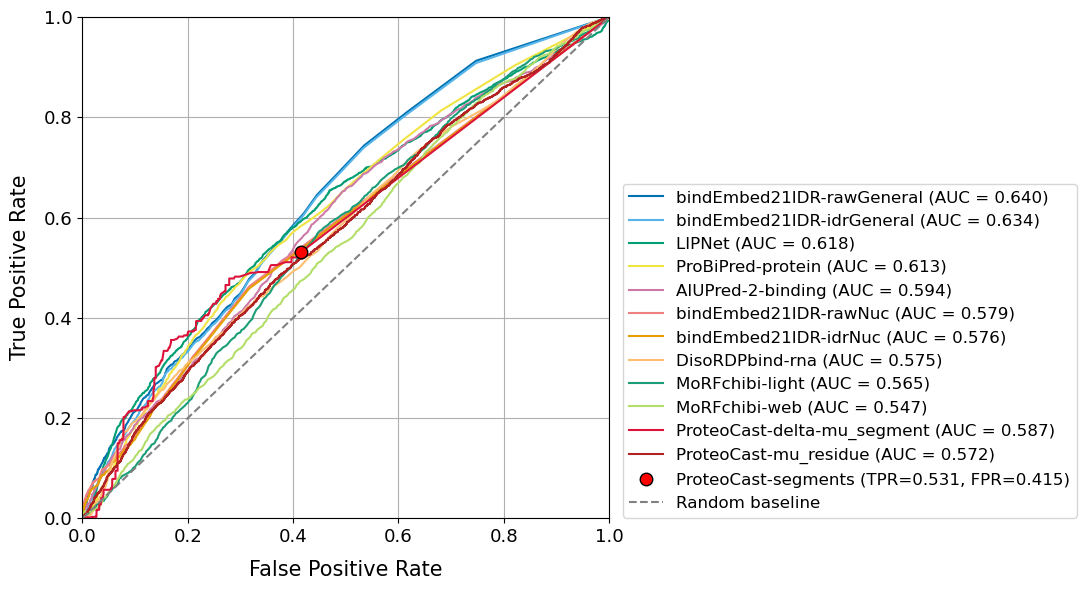

{'bindEmbed21IDR-rawGeneral': 0.5728485482605284,
 'bindEmbed21IDR-idrGeneral': 0.5706044316244919,
 'MoRFchibi-web': 0.5512634977179116,
 'LIPNet': 0.5446579988694178,
 'AIUPred-2-binding': 0.5345955728804122,
 'MoRFchibi-light': 0.5002223869532987,
 'ProteoCast-delta-mu_segment': 0.49761610453823063,
 'ProBiPred-protein': 0.4908625106746371,
 'ProteoCast_binary': 0.484275755228505,
 'bindEmbed21IDR-rawNuc': 0.47032436162870944,
 'bindEmbed21IDR-idrNuc': 0.4668627790275134,
 'ProteoCast-mu_residue': 0.46573107049608353,
 'ProteoCast_binary_2': 0.4286265432098765,
 'DisoRDPbind-rna': 0.3710987601539119}

In [170]:
from sklearn.metrics import log_loss

d_f1score = {}
#df_tmp = df_CAIDall_plddt.copy()
#df_tmp = df_CAIDall.copy()
df_tmp = df_CAIDall.loc[df_CAIDall['idr_caid']!='-'].copy()

df_tmp['ProteoCast_binary'] = df_tmp['ProteoCast'].apply(lambda x: 1 if x in [1.0, 2.0] else 0.0) ## 1 and 2 are considered as detected

#df_tmp['ProteoCast_binary'] = df_tmp['ProteoCast_uninformed'].apply(lambda x: 1 if x in [1.0, 2.0] else 0.0) ## 1 and 2 are considered as detected
#df_tmp['ProteoCast_binary'] = df_tmp['ProteoCast_uninformed'].apply(lambda x: 1 if x == 2.0 else 0.0) ## only 2 is considered as detected


# Get true and predicted labels
y_true = df_tmp['binding']
print(f"Number of true binding residues: {y_true.sum()} out of {len(y_true)}")
y_pred = df_tmp['ProteoCast_binary']
# Compute confusion matrix: [[TN, FP], [FN, TP]]
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
# Compute TPR (Recall or Sensitivity) and FPR
tpr_ProteoCast = tp / (tp + fn) if (tp + fn) > 0 else 0
fpr_ProteoCast = fp / (fp + tn) if (fp + tn) > 0 else 0
f1 = f1_score(y_true, y_pred)
d_f1score['ProteoCast_binary'] = f1
print(f"ProteoCast: TPR={tpr_ProteoCast:.3f}, FPR={fpr_ProteoCast:.3f}, F1={f1:.3f}")

df_tmp['ProteoCast_binary'] = df_tmp['ProteoCast'].apply(lambda x: 1 if x == 2.0 else 0.0) ## only 2 is considered as detected
y_pred = df_tmp['ProteoCast_binary']
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
# Compute TPR (Recall or Sensitivity) and FPR
tpr_ProteoCast_2 = tp / (tp + fn) if (tp + fn) > 0 else 0
fpr_ProteoCast_2 = fp / (fp + tn) if (fp + tn) > 0 else 0
f1_2 = f1_score(y_true, y_pred)
d_f1score['ProteoCast_binary_2'] = f1_2



palette = [
    "#0072B2",  # Blue
    "#56B4E9",  # Light Blue
    "#009E73",  # Green
    "#F0E442",  # Yellow
    "#CC79A7",  # Purple
    "lightcoral",  # Orange
    "#E69F00",  # Gold
    "#FDBF6F",  # Peach
    "#1B9E77",  # Teal
    "#B3DE69",  # Light Green
    "#DC143C",  # Tomato
    "#B22222"  # Crimson
]
### ROC curves for all other models

plt.figure(figsize=(11, 6))

for color, model in zip(palette, l_top10CAID3_binding_IDR+['ProteoCast-delta-mu_segment']+['ProteoCast-mu_residue']):
    try:
        temp_df = df_tmp[['binding', model]].dropna()
    except:
        print(f"Model {model} not found in the DataFrame.")
        continue
    
    y_true = temp_df['binding']
    y_score = temp_df[model]
    fpr, tpr, thresh = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    # Youden's J statistic
    j_scores = tpr - fpr
    best_index = j_scores.argmax()
    best_threshold = thresh[best_index] 

    # Binary predictions at best threshold
    y_pred = (y_score >= best_threshold).astype(int)
    f1 = f1_score(y_true, y_pred)
    d_f1score[model] = f1
    # Plot ROC curve and dot with same color
    curve, = plt.plot(fpr, tpr, label=f'{model} (AUC = {roc_auc:.3f})', color=color)
    #plt.plot(fpr[best_index], tpr[best_index], 'o', markersize=9, label=model, color=curve.get_color(), markeredgecolor='black', markeredgewidth=1)

    print(f"{model}: TPR={tpr[best_index]:.3f}, FPR={fpr[best_index]:.3f}, Threshold={best_threshold:.3f}, F1={f1:.3f}")

    ###cross entropy


    # y_true : 1-D array of 0/1 labels
    # y_prob : 1-D array of predicted probabilities (0 ≤ p ≤ 1)
    loss = log_loss(y_true, y_score)     # average BCE over all residues
    print(f"Cross-entropy (log-loss): {loss:.4f}")



plt.plot(fpr_ProteoCast, tpr_ProteoCast, 'o', color='red', markersize=9, label='ProteoCast-segments (TPR=0.531, FPR=0.415)', markeredgecolor='black', markeredgewidth=1)
#plt.plot(fpr_ProteoCast_2, tpr_ProteoCast_2, 'o', color='darkred', markersize=9, label='ProteoCast (2 segments)', markeredgecolor='black', markeredgewidth=1)

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random baseline')
#plt.plot(fpr_ProteoCast, tpr_ProteoCast, 'o', color='red', markersize=9, label='ProteoCast (2)', markeredgecolor='black', markeredgewidth=1)
plt.xlabel('False Positive Rate', fontsize=15, labelpad=10)
plt.ylabel('True Positive Rate', fontsize=15, labelpad=10)
#plt.title('ROC Curve for Binding Prediction (pLDDT<0.7)', fontsize=14)
plt.legend(loc='lower left', fontsize=12, bbox_to_anchor=(1.01, -0.015))
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.grid(True)
plt.tight_layout()
plt.savefig('CAID3_ROC_curve_binding_prediction.jpg', dpi=700)
plt.show()
d_f1score_sorted = dict(sorted(d_f1score.items(), key=lambda item: item[1], reverse=True))
d_f1score_sorted



In [51]:
df_tmp['ProteoCast_combined'] = df_tmp[['ProteoCast-mu_residue', 'ProteoCast-delta-mu_segment']].mean(axis=1)

thresh: 0.03999218, 0.       
fpr  0.41469649, 1.     
tpr  0.53073005, 1.    

In [8]:
df_CAIDall.to_csv('df_CAIDall.csv', index=False)

In [4]:
df_CAIDall = pd.read_csv('df_CAIDall.csv')

In [24]:
from pathlib import Path

# Define the output file
output_path = Path("predictions/proteocast_labels1_2.caid")
# Group by protein ID and format each group
with open(output_path, "w") as f:
    for protein_id, group in df_CAIDall.groupby("id"):
        f.write(f">{protein_id}\n")
        for _, row in group.iterrows():
            line = f"{int(row['pos'])}\t{row['aa']}\t\t{row['ProteoCast_binary']:.3f}"
            f.write(f"{line}\n")

#### attemp to make vectorized_metrics work 

In [5]:
l_top10CAID3_binding_IDR = ['bindEmbed21IDR-rawGeneral', 'bindEmbed21IDR-idrGeneral', 'LIPNet', 'ProBiPred-protein', 'AIUPred-2-binding', 'bindEmbed21IDR-rawNuc', 'bindEmbed21IDR-idrNuc', 'DisoRDPbind-rna', 'MoRFchibi-light', 'MoRFchibi-web' ]
l_topIDR = l_top10CAID3_binding_IDR + ['proteocast_delta_output', 'proteocast_mu_residue', 'proteocast_labels1_2']
l_topIDR = ['/Users/manchuta/Desktop/CAID3/predictions/'+x+'.caid' for x in l_topIDR]
print(l_topIDR)
bvaluation('binding_idr.fasta', l_topIDR)


['/Users/manchuta/Desktop/CAID3/predictions/bindEmbed21IDR-rawGeneral.caid', '/Users/manchuta/Desktop/CAID3/predictions/bindEmbed21IDR-idrGeneral.caid', '/Users/manchuta/Desktop/CAID3/predictions/LIPNet.caid', '/Users/manchuta/Desktop/CAID3/predictions/ProBiPred-protein.caid', '/Users/manchuta/Desktop/CAID3/predictions/AIUPred-2-binding.caid', '/Users/manchuta/Desktop/CAID3/predictions/bindEmbed21IDR-rawNuc.caid', '/Users/manchuta/Desktop/CAID3/predictions/bindEmbed21IDR-idrNuc.caid', '/Users/manchuta/Desktop/CAID3/predictions/DisoRDPbind-rna.caid', '/Users/manchuta/Desktop/CAID3/predictions/MoRFchibi-light.caid', '/Users/manchuta/Desktop/CAID3/predictions/MoRFchibi-web.caid', '/Users/manchuta/Desktop/CAID3/predictions/proteocast_delta_output.caid', '/Users/manchuta/Desktop/CAID3/predictions/proteocast_mu_residue.caid', '/Users/manchuta/Desktop/CAID3/predictions/proteocast_labels1_2.caid']


In [118]:
df_results = pd.read_csv('binding_idr.analysis.all.dataset.default.metrics.csv')
df_results.sort_values(by='aucroc', ascending=False)


,Unnamed: 0,bac,csi,f05,f1s,f2s,fnr,fom,fpr,inf,mcc,mk,npv,ppv,tnr,tpr,aucroc,aucpr,aps,thr
0,bindEmbed21IDR-rawGeneral,0.514,0.037,0.154,0.070,0.046,0.963,0.380,0.009,0.028,0.099,0.343,0.620,0.723,0.991,0.037,0.641,0.517,0.514,0.501
1,bindEmbed21IDR-idrGeneral,0.504,0.012,0.056,0.024,0.015,0.988,0.385,0.005,0.007,0.043,0.242,0.615,0.627,0.995,0.012,0.635,0.500,0.497,0.503
2,LIPNet,0.587,0.364,0.491,0.533,0.583,0.378,0.301,0.448,0.174,0.170,0.166,0.699,0.467,0.552,0.622,0.619,0.507,0.507,0.500
3,ProBiPred-protein,0.502,0.017,0.077,0.035,0.022,0.982,0.386,0.015,0.003,0.012,0.048,0.614,0.434,0.985,0.018,0.613,0.474,0.472,0.501
4,AIUPred-2-binding,0.505,0.014,0.065,0.027,0.017,0.986,0.384,0.004,0.010,0.054,0.293,0.616,0.677,0.996,0.014,0.590,0.471,0.470,0.501
10,proteocast_delta_output,0.558,0.320,0.460,0.484,0.511,0.469,0.335,0.415,0.116,0.113,0.110,0.665,0.445,0.585,0.531,0.587,0.464,0.455,0.040
5,bindEmbed21IDR-rawNuc,0.511,0.024,0.108,0.047,0.030,0.976,0.381,0.003,0.021,0.101,0.476,0.619,0.857,0.997,0.024,0.582,0.492,0.467,0.503
6,bindEmbed21IDR-idrNuc,0.503,0.006,0.029,0.012,0.007,0.994,0.385,0.000,0.006,0.056,0.520,0.615,0.905,1.000,0.006,0.579,0.486,0.460,0.503
7,DisoRDPbind-rna,0.508,0.050,0.181,0.094,0.063,0.948,0.382,0.037,0.015,0.038,0.092,0.618,0.474,0.963,0.052,0.575,0.454,0.454,0.151
11,proteocast_mu_residue,0.543,0.206,0.414,0.342,0.291,0.735,0.360,0.178,0.087,0.103,0.122,0.640,0.482,0.822,0.265,0.572,0.448,0.448,0.500


In [ ]:
df_results_roc = pd.read_csv('binding_idr.analysis.all.dataset.bac.metrics.csv')


In [122]:
df_results_bac = pd.read_csv('binding_idr.analysis.all.dataset.bac.metrics.csv')
df_results_bac.sort_values(by='aucroc', ascending=False)

,Unnamed: 0,bac,csi,f05,f1s,f2s,fnr,fom,fpr,inf,mcc,mk,npv,ppv,tnr,tpr,aucroc,aucpr,aps,thr
0,bindEmbed21IDR-rawGeneral,0.604,0.402,0.504,0.574,0.667,0.252,0.257,0.540,0.208,0.208,0.209,0.743,0.466,0.460,0.748,0.641,0.517,0.514,0.003
1,bindEmbed21IDR-idrGeneral,0.602,0.400,0.503,0.572,0.664,0.257,0.260,0.539,0.204,0.204,0.205,0.740,0.465,0.461,0.743,0.635,0.500,0.497,0.003
2,LIPNet,0.592,0.375,0.495,0.546,0.608,0.342,0.291,0.475,0.183,0.179,0.175,0.709,0.466,0.525,0.658,0.619,0.507,0.507,0.451
3,ProBiPred-protein,0.587,0.325,0.493,0.490,0.488,0.513,0.320,0.314,0.173,0.174,0.174,0.680,0.494,0.686,0.487,0.613,0.474,0.472,0.022
4,AIUPred-2-binding,0.577,0.364,0.482,0.534,0.600,0.347,0.304,0.499,0.154,0.150,0.148,0.696,0.452,0.501,0.653,0.590,0.471,0.470,0.122
10,proteocast_delta_output,0.600,0.331,0.509,0.497,0.485,0.522,0.312,0.279,0.199,0.203,0.206,0.688,0.518,0.721,0.478,0.587,0.464,0.455,0.166
5,bindEmbed21IDR-rawNuc,0.575,0.312,0.478,0.475,0.473,0.529,0.329,0.322,0.149,0.150,0.151,0.671,0.480,0.678,0.471,0.582,0.492,0.467,0.001
6,bindEmbed21IDR-idrNuc,0.573,0.309,0.476,0.472,0.468,0.534,0.331,0.321,0.145,0.146,0.147,0.669,0.478,0.679,0.466,0.579,0.486,0.460,0.001
7,DisoRDPbind-rna,0.554,0.231,0.440,0.375,0.328,0.698,0.353,0.193,0.109,0.125,0.143,0.647,0.496,0.807,0.302,0.575,0.454,0.454,0.055
11,proteocast_mu_residue,0.555,0.297,0.454,0.458,0.463,0.534,0.342,0.356,0.110,0.109,0.109,0.658,0.451,0.644,0.466,0.572,0.448,0.448,0.330


In [115]:
df_results_f1s = pd.read_csv('binding_idr.analysis.all.dataset.f1s.metrics.csv')
df_results_f1s.sort_values(by='aucroc', ascending=False)

,Unnamed: 0,bac,csi,f05,f1s,f2s,fnr,fom,fpr,inf,mcc,mk,npv,ppv,tnr,tpr,aucroc,aucpr,aps,thr
0,bindEmbed21IDR-rawGeneral,0.582,0.417,0.485,0.589,0.748,0.086,0.178,0.751,0.163,0.205,0.256,0.822,0.434,0.249,0.914,0.641,0.517,0.514,0.001
1,bindEmbed21IDR-idrGeneral,0.580,0.415,0.484,0.587,0.745,0.091,0.186,0.750,0.159,0.199,0.247,0.814,0.433,0.250,0.909,0.635,0.500,0.497,0.001
2,LIPNet,0.551,0.387,0.464,0.558,0.699,0.159,0.278,0.740,0.101,0.119,0.139,0.722,0.417,0.260,0.841,0.619,0.507,0.507,0.176
3,ProBiPred-protein,0.541,0.392,0.459,0.563,0.728,0.095,0.253,0.823,0.082,0.113,0.156,0.747,0.409,0.177,0.905,0.613,0.474,0.472,0.001
4,AIUPred-2-binding,0.500,0.386,0.440,0.557,0.759,0.000,1.000,1.000,0.000,0.000,-0.614,0.000,0.386,0.000,1.000,0.590,0.471,0.470,0.000
10,proteocast_delta_output,0.500,0.385,0.439,0.556,0.758,0.000,1.000,1.000,0.000,0.000,-0.615,0.000,0.385,0.000,1.000,0.587,0.464,0.455,0.000
5,bindEmbed21IDR-rawNuc,0.500,0.386,0.440,0.557,0.759,0.000,1.000,1.000,0.000,0.000,-0.614,0.000,0.386,0.000,1.000,0.582,0.492,0.467,0.000
6,bindEmbed21IDR-idrNuc,0.500,0.386,0.440,0.557,0.759,0.000,1.000,1.000,0.000,0.000,-0.614,0.000,0.386,0.000,1.000,0.579,0.486,0.460,0.000
7,DisoRDPbind-rna,0.516,0.390,0.447,0.561,0.752,0.026,0.224,0.943,0.031,0.073,0.170,0.776,0.394,0.057,0.974,0.575,0.454,0.454,0.004
11,proteocast_mu_residue,0.515,0.389,0.446,0.561,0.753,0.023,0.217,0.947,0.030,0.072,0.176,0.783,0.393,0.053,0.977,0.572,0.448,0.448,0.028


#### Plot the binding sites

In [ ]:
segments_grouped = df_CAIDall.groupby('id')


for protein, group in segments_grouped:
    print(protein)
    id_prot = df_mapping[df_mapping['name'] == protein]['id'].values[0]
    data = pd.read_csv(f'final/{str(id_prot)}/14.101_GEMME_pLDDT.csv', sep=',')


    signal = pd.DataFrame({
        'x': list(range(1, len(data) + 1)),
        'y': list(data['GEMME_mean']),
        'type': ['GEMME'] * len(data)
    })
    
    gemme = pd.read_csv(f'final/{str(id_prot)}/8.101_Segmentation.csv', sep=',')
    gemme = gemme[gemme['type'] == 'GEMME']

    cp = pd.DataFrame({
        'x': list(gemme['end'][:-1]),'type': ['GEMME'] * (len(gemme) - 1)})
    mean = pd.DataFrame({
        'x': list(gemme['start'] - 1),'xend': list(gemme['end']),
        'y': list(gemme['mean']),'type': ['GEMME'] * len(gemme),
        'state': list(gemme['state'])
    })

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 5), gridspec_kw={'height_ratios': [1, 6]})
    # Plot GEMME on the top subplot
    for _, row in mean[mean['type'] == 'GEMME'].iterrows():
        ax2.axvspan(row['x'], row['xend'], color='white' if row['state'] == 0 else 'red' if row['state'] == 1 else 'purple', alpha=0.1)
    ax2.plot(signal[signal['type'] == 'GEMME']['x'], signal[signal['type'] == 'GEMME']['y'], label='GEMME', linewidth=1.3)

    for _, row in cp[cp['type'] == 'GEMME'].iterrows():
        ax2.axvline(row['x'], color='red', alpha=0.9, linewidth=1.3)
    for _, row in mean[mean['type'] == 'GEMME'].iterrows():
        ax2.plot([row['x'], row['xend']], [row['y'], row['y']], color='black',linewidth=1, alpha=0.75)
    ax2.set_ylabel('Average predicted score', fontsize=17, labelpad=10)
    ax2.set_xlim(1, len(group))

    binding_positions = group.loc[group['binding'] == 1, 'pos'].values
    ax2.hlines(y=0.8, xmin=binding_positions.min(), xmax=binding_positions.max(), colors='blue', linewidth=6, label='Binding=1 (y=0.8)')



    
    palette_bis={0:'#FF7D45', 1:'#FFDB13', 2:'#65CBF3', 3:'#0053D6'}
    bins = [0, 50, 70, 90, 100]
    df = pd.DataFrame(list(group['pLDDT']*100), columns=['value'])
    # Bin the values into groups
    df['group'] = pd.cut(df['value'], bins=bins, labels=[0,1,2,3], right=False)
    grouped_values_numeric = np.array(df['group'])

    # Reshape to a one-row matrix with 395 columns
    data_matrix = grouped_values_numeric.reshape(1, -1)

    # Map the palette to colors for the heatmap
    colors = [palette_bis[val] for val in sorted(palette_bis.keys())]
    cmap = sns.color_palette(colors, len(colors))
    sns.heatmap(data_matrix, cmap=cmap, linewidths=0, cbar=False, xticklabels=False, yticklabels=False, alpha=0.85, ax=ax1)


    # Adjust xticks for ax2
    xticks = range(50, len(group) + 1, 50)
    ax2.set_xticks(xticks)
    ax2.set_xticklabels([str(x) for x in xticks], fontsize=15)
    ax2.set_yticklabels([str(round(x, 1)) for x in ax2.get_yticks()], fontsize=15)

    # Remove x-axis ticks and labels from ax1
    ax1.set_xticks([])
    ax1.set_xticklabels([])
    ax1.set_xlim(1, len(group))
    ax2.set_xlim(1, len(group))


    plt.xlabel('Residue index', fontsize=20, labelpad=12)
    plt.subplots_adjust(hspace=0.05)
    #fig.suptitle(protein, fontsize=17, y=0.95)
    plt.tight_layout()
    #plt.show()
    plt.savefig('final/plots/' + protein + '.jpg', dpi=500)
    plt.close(fig)
